<a href="https://colab.research.google.com/github/filfish2007-cav/ITStep-AI/blob/superwised_learning/%D0%94%D0%97_%D0%BE%D0%B1%D1%80%D0%BE%D0%B1%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85(%D1%85%D0%B0%D1%82%D0%B8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [ ]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [4]:
df.info()
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 482.0+ KB


,0
Posted On,367
BHK,404
Rent,377
Size,344
Floor,366
Area Type,356
Area Locality,399
City,358
Furnishing Status,351
Tenant Preferred,374


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

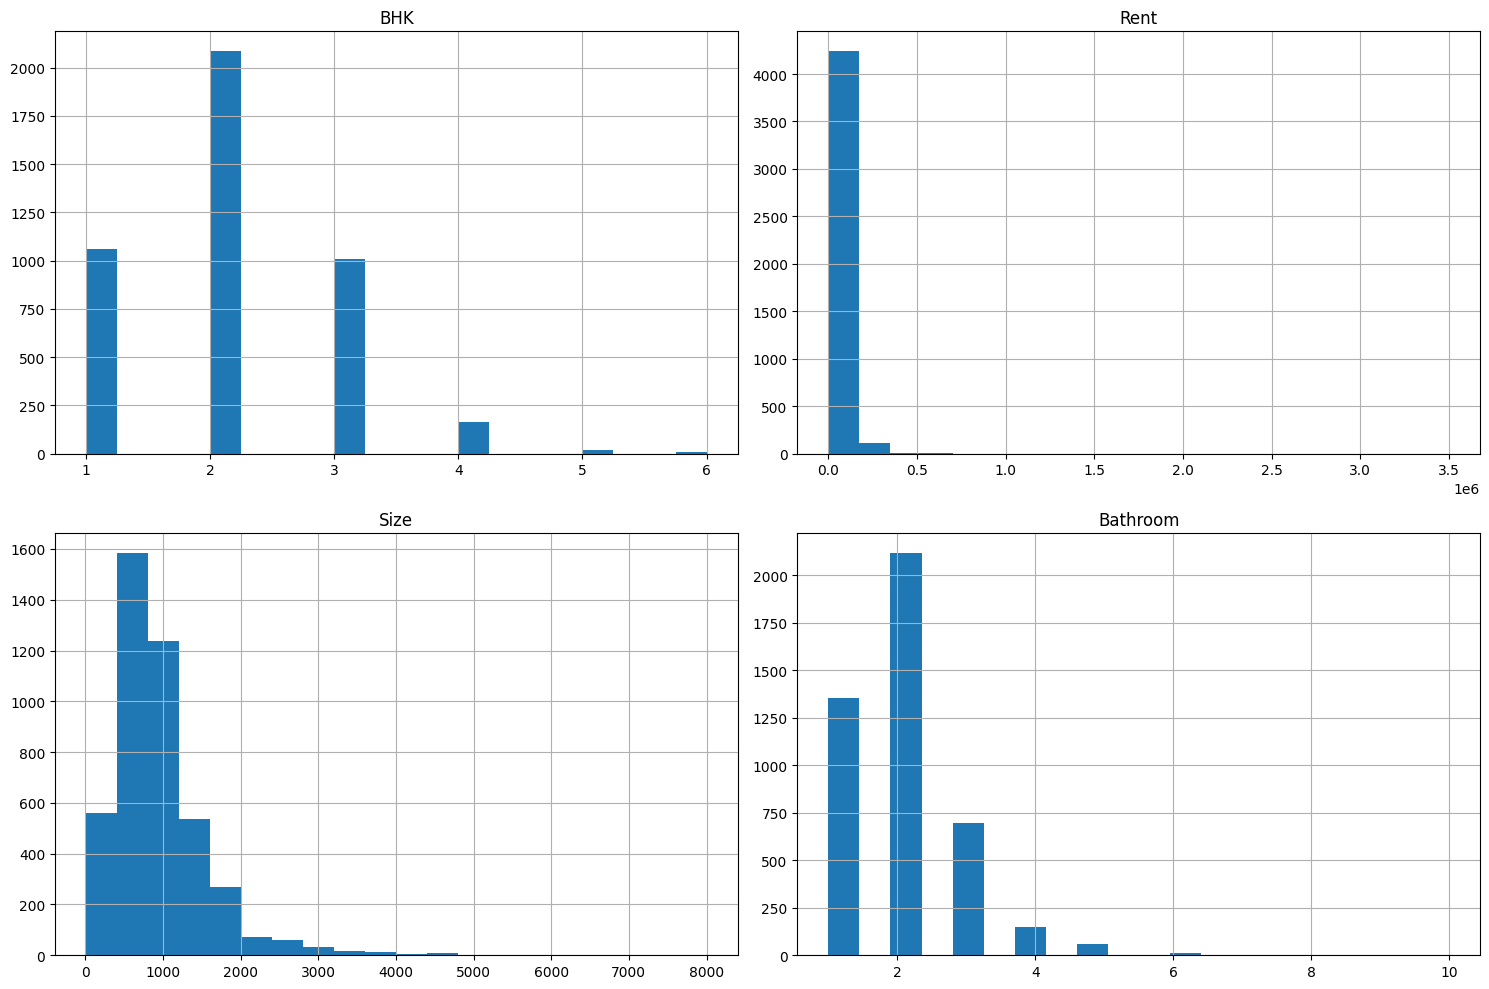

In [5]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Створюємо гістограми
df[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

In [12]:
mask = df['BHK'] < 0.3 * 1e6
mask.sum()



np.int64(4342)

In [ ]:
df = df[mask]

<Axes: >

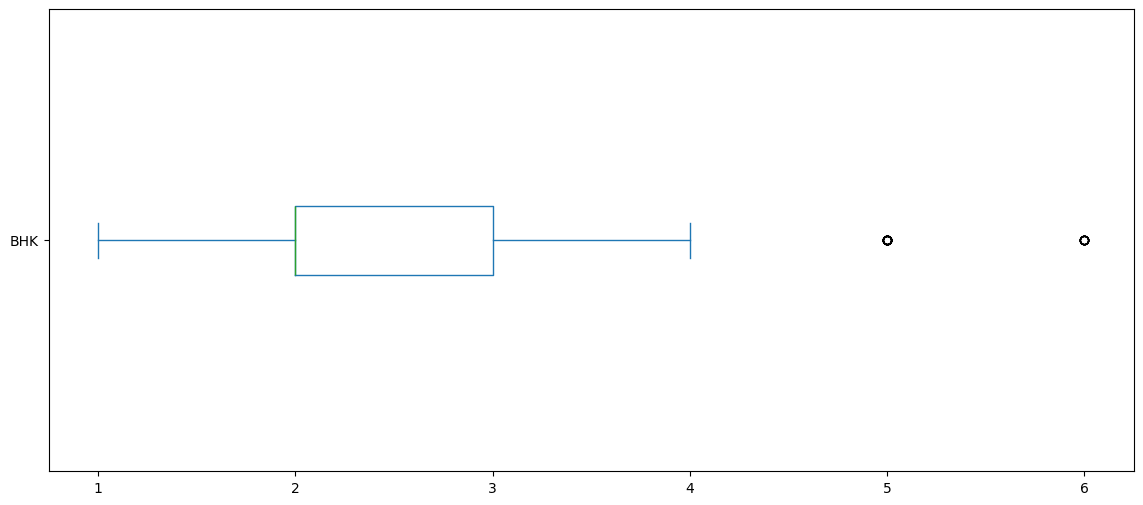

In [11]:
df['BHK'].plot(kind='box', vert=False,figsize=(14,6))

In [21]:
mask = df['Rent'] <= 280000
mask.sum()



np.int64(3954)

In [22]:
df = df[mask]

count      3954.000000
mean      29748.483055
std       38547.219064
min        1200.000000
25%       10000.000000
50%       16000.000000
75%       32000.000000
90%       65000.000000
95%      100000.000000
99%      200000.000000
max      280000.000000
Name: Rent, dtype: float64


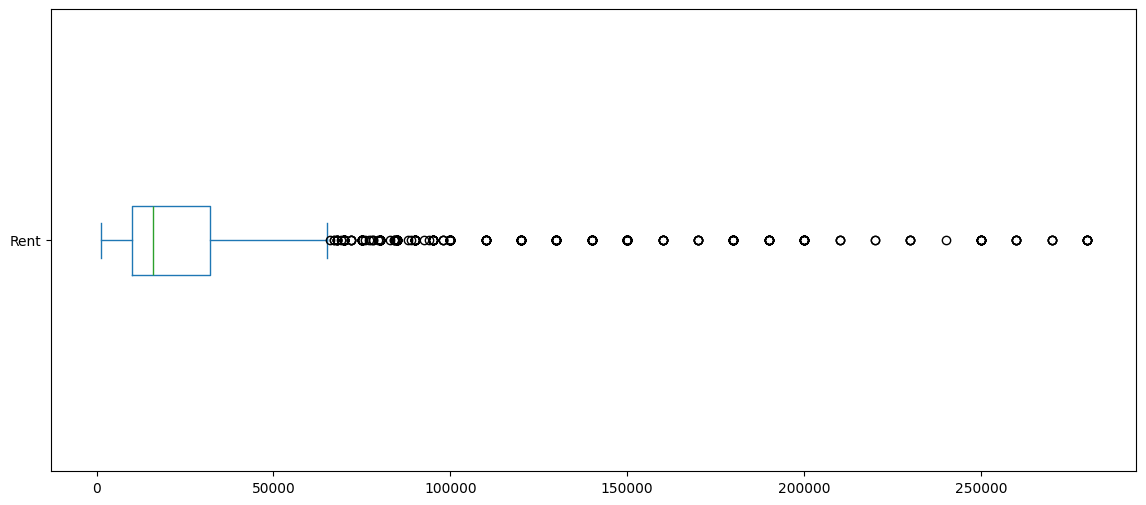

In [23]:
df['Rent'].plot(kind='box', vert=False,figsize=(14,6))
# Смотрим на текстовое описание распределения
print(df['Rent'].describe(percentiles=[0.25,0.5, 0.75, 0.9, 0.95, 0.99]))


In [27]:
mask = df['Size'] <= 3137
mask.sum()



np.int64(3640)

In [28]:
df = df[mask]

count    3640.000000
mean      919.287088
std       511.303031
min        10.000000
25%       550.000000
50%       841.500000
75%      1200.000000
90%      1600.000000
95%      1851.100000
99%      2600.000000
max      3133.000000
Name: Size, dtype: float64


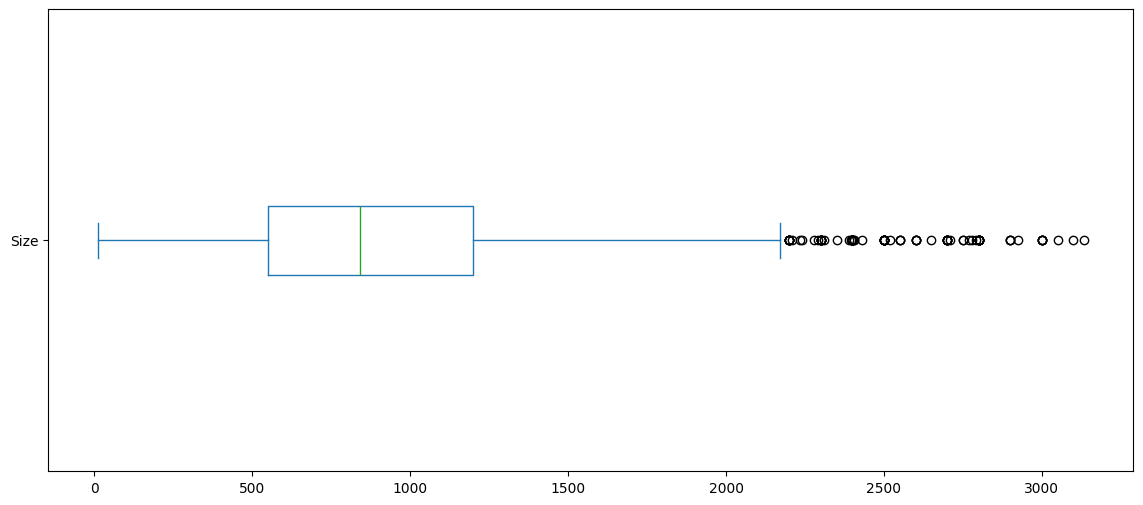

In [29]:
df['Size'].plot(kind='box', vert=False,figsize=(14,6))
print(df['Size'].describe(percentiles=[0.25,0.5, 0.75, 0.9, 0.95, 0.99]))

In [31]:
mask = df['Bathroom'] <= 4
mask.sum()



np.int64(3330)

In [32]:
df = df[mask]

count    3330.000000
mean        1.891892
std         0.750904
min         1.000000
25%         1.000000
50%         2.000000
75%         2.000000
90%         3.000000
95%         3.000000
99%         4.000000
max         4.000000
Name: Bathroom, dtype: float64


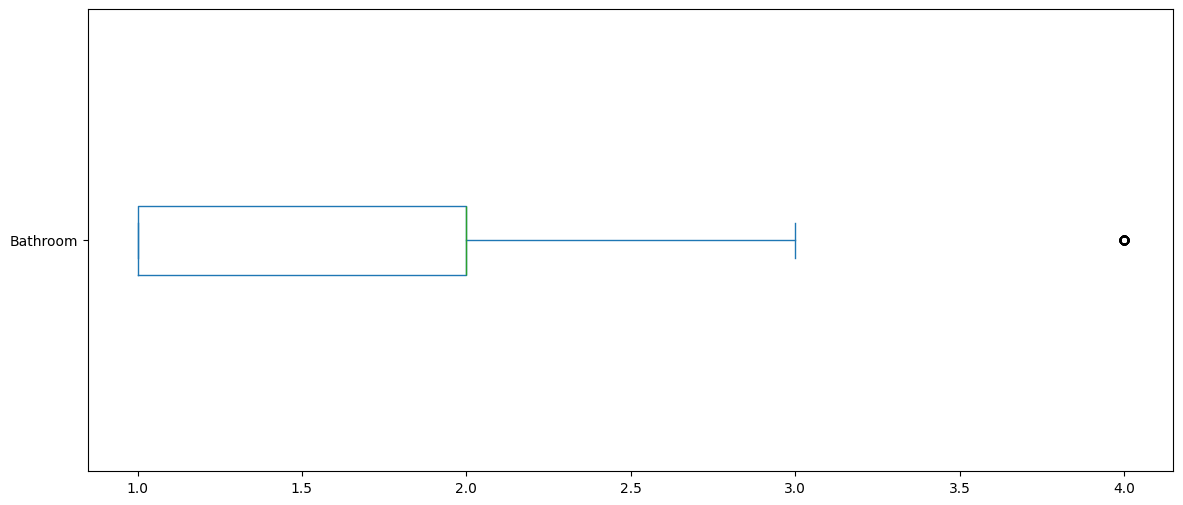

In [33]:
df['Bathroom'].plot(kind='box', vert=False,figsize=(14,6))
print(df['Bathroom'].describe(percentiles=[0.25,0.5, 0.75, 0.9, 0.95, 0.99]))

# Завдання 4
Створіть Pipeline для обробки даних